# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_time_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32


2026-04-16 21:55:37.676453: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 21:55:37.685160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 21:55:37.697967: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 21:55:37.697994: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 21:55:37.706308: I tensorflow/core/platform/cpu_feature_gua

In [3]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.


2026-04-16 21:55:41.629795: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [4]:

import numpy as np
from utils import get_flops_native


class CustomFrontend(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

In [5]:
NUM_FILTERS = 40
DENSE_HIDDEN = 64
KERNEL_SIZE = 64
STRIDE = 8
def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS, 
        kernel_size=KERNEL_SIZE, 
        stride=STRIDE, 
        name="sinc_frontend")(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None)(x)
    return tf.keras.Model(inputs, outputs, name="sincnet_time_training")


training_model = build_training_model(num_labels)
training_model.summary()
flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_time_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 5977, 40)       │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 5977, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 40)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314 (20.76 KB)

 Trainable params: 5,314 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 30846762


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-16 21:55:42.430562: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-16 21:55:42.431507: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-16 21:55:42.431579: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-16 21:55:42.432099: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUM

In [6]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb("sincnet", config={
    "num_filters": NUM_FILTERS,
    "kernel_size": KERNEL_SIZE,
    "stride": STRIDE,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776369344.532400  165331 service.cc:145] XLA service 0x76898c004d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776369344.532438  165331 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-16 21:55:44.552975: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 21:55:44.654467: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 19/353 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6005 - loss: 0.6876

I0000 00:00:1776369346.462717  165331 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.7790 - loss: 0.4532 - val_accuracy: 0.9290 - val_loss: 0.2646
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9163 - loss: 0.2527 - val_accuracy: 0.9319 - val_loss: 0.2051
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9274 - loss: 0.2177 - val_accuracy: 0.9413 - val_loss: 0.1729
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9392 - loss: 0.1914 - val_accuracy: 0.9529 - val_loss: 0.1489
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9458 - loss: 0.1737 - val_accuracy: 0.9572 - val_loss: 0.1371
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9501 - loss: 0.1592 - val_accuracy: 0.9580 - val_loss: 0.1257
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9516 - loss: 0.1469 - val_accuracy: 0.9609 - val_loss: 0.1152
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9522 - loss: 0.1384 - val_

batch/accuracy,▁▃▃▄▄▅▆▅▅▆▆▆▆▆▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▆▇▇▇▇▇████
batch/batch_step,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▅▄▄▄▄▃▃▃▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▂▁▂▁▁▁▁▁▁
epoch/accuracy,▁▃▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
epoch/epoch,▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▂▄▅▅▅▅▅▅▅▆▅▆▆▆▅▅▅▆▆▅▆▆▆▇▇▇▇█▇▇█▇█▇█▇█
epoch/val_loss,█▆▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...


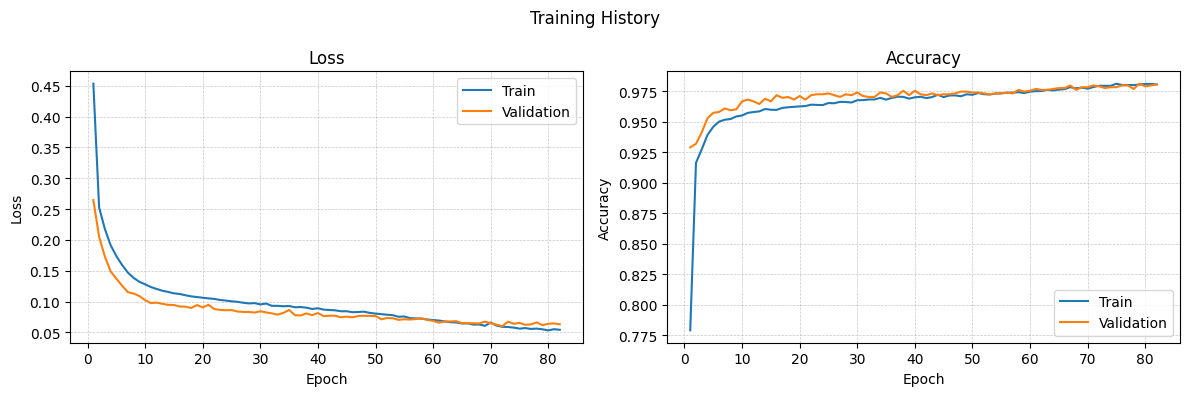

In [7]:
from utils import plot_training_history
plot_training_history(history)

## Make frontend filters into a Conv1D inference model


In [8]:
# Extract the trained custom frontend and bake its filters
custom_layer = None
for layer in training_model.layers:
    if isinstance(layer, CustomFrontend):
        custom_layer = layer
        break

if custom_layer is None:
    raise RuntimeError("CustomFrontend layer not found in training_model")

baked_filters = custom_layer.get_filters().numpy()

# Build Conv1D-based inference model
infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = tf.keras.layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    strides=STRIDE,
    padding="valid",
    use_bias=False,
    name="baked_conv",
)(infer_inputs)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(64, activation="relu", name="dense_hidden")(x)
infer_outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

inference_model = tf.keras.Model(infer_inputs, infer_outputs, name="sincnet_time_inference")

# Copy weights
inference_model.get_layer("baked_conv").set_weights([baked_filters])
inference_model.get_layer("dense_hidden").set_weights(
    training_model.layers[-2].get_weights()
)
inference_model.get_layer("dense_logits").set_weights(
    training_model.layers[-1].get_weights()
)

# Optional parity check on a small batch
for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print("Max abs diff between training and inference logits:", np.max(np.abs(logits_train - logits_infer)))

Max abs diff between training and inference logits: 88.14785


2026-04-16 22:21:42.791991: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [9]:
rep_batches = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  130338458550864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130338458551392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130338458552448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130338458551568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130338458552800: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-16 22:21:43.099375: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
W0000 00:00:1776370903.278658  165218 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776370903.278676  165218 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-16 22:21:43.278993: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-16 22:21:43.279353: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 22:21:43.279362: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-16 22:21:43.283020: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-16 22:21:43.283489: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-16 22:21:43.301093: I tensorflow/cc/saved_model/

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-04-16 22:22:29.130549: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-16 22:22:35.505176: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/utils.py:580: RuntimeWarning: invalid value encountered in divide
  f2_c = np.where(denom > 0, 5 * prec_c[:-1] * rec_c[:-1] / denom, 0.0)


Model size : 5.7 KB
Est. MFLOPs: 0.672
Arena size : 560.6 KB
=== Binary classifier metrics : TEST SET===
Threshold: 0.0922  (best F2 threshold)
Accuracy : 0.3833
Precision: 0.3452
Recall   : 0.9760
F2 score : 0.7147
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.6415


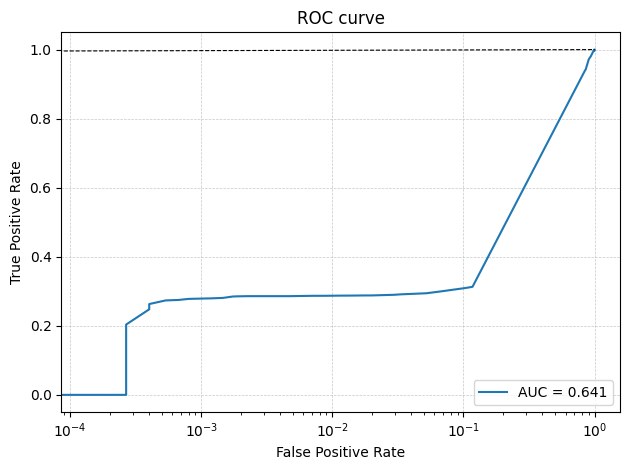

Avg inference: 4.088 ms


In [10]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")